In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/processed_data_3/sales_data_eda_ready.csv")

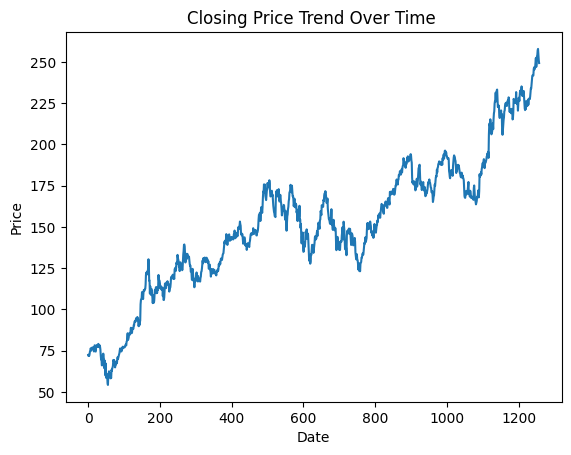

In [3]:
##  Price Trend Over Time (Core Insight)

plt.Figure(figsize=(20, 6))
plt.plot(df.index , df["Close"] , label = "Close Price")
plt.title("Closing Price Trend Over Time ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

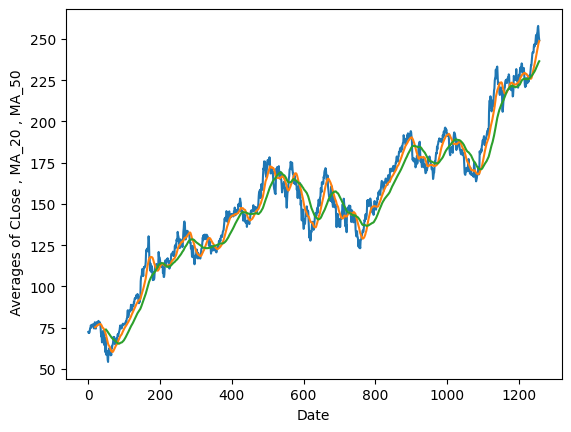

In [4]:
plt.Figure(figsize = ( 12 , 6))
plt.plot(df.index, df["Close"], label=["Close Price"])
plt.plot(df.index , df["MA_20"] , label = "20-Day MA")
plt.plot(df.index , df["MA_50"] , label = "50-Day MA")
plt.xlabel("Date")
plt.ylabel(" Averages of CLose , MA_20 , MA_50")
plt.show()

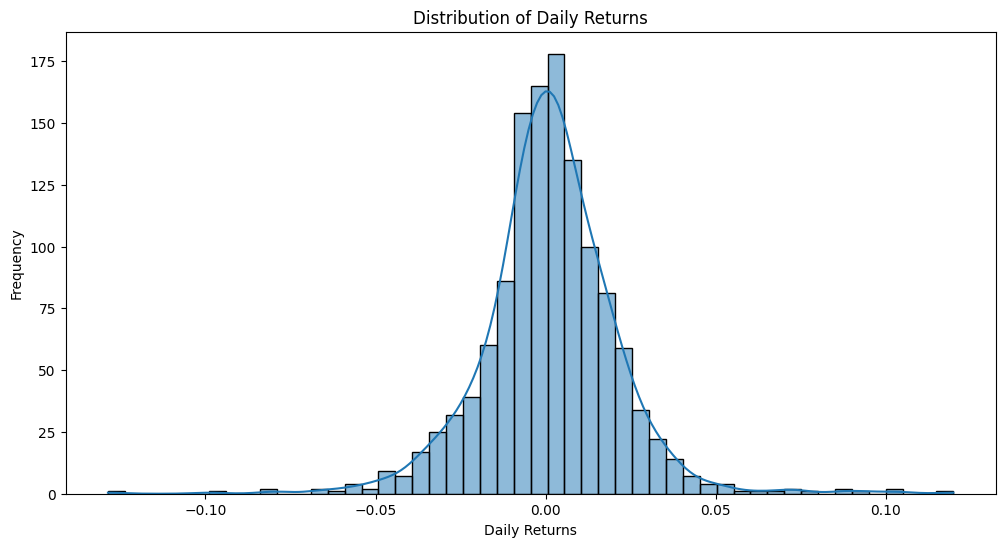

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Daily_Return"] , bins = 50 , kde =True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.show()

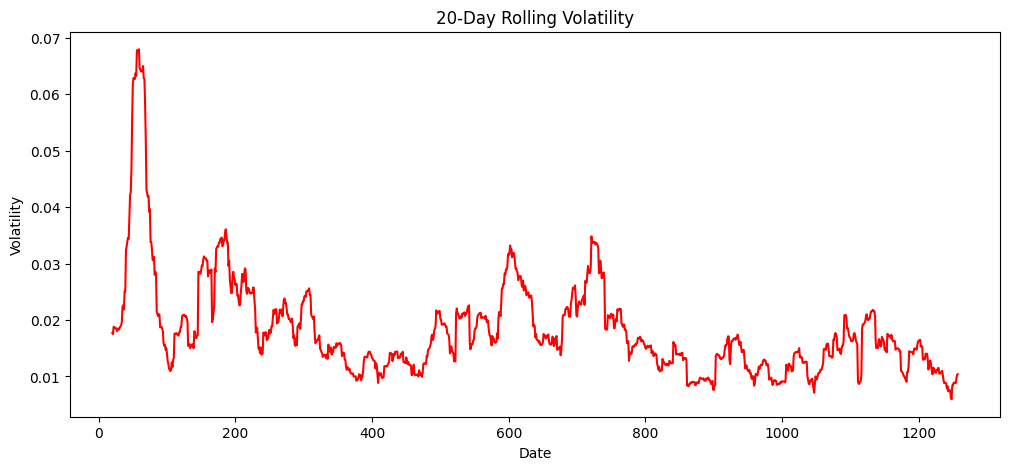

In [6]:
df["Volatility_20"] = df["Daily_Return"].rolling(20).std()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Volatility_20"], color="red")

plt.title("20‑Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

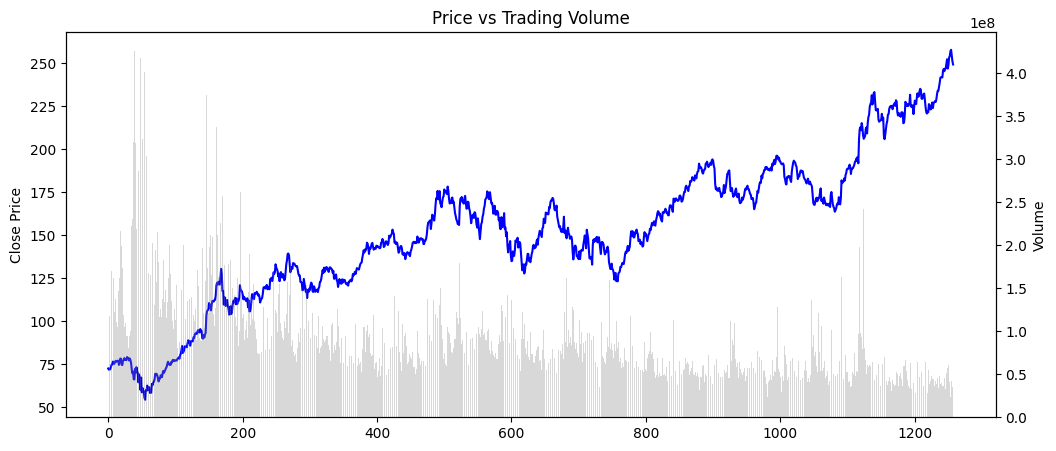

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df.index, df["Close"], color="blue")
ax1.set_ylabel("Close Price")

ax2 = ax1.twinx()
ax2.bar(df.index, df["Volume"], alpha=0.3, color="gray")
ax2.set_ylabel("Volume")

plt.title("Price vs Trading Volume")
plt.show()

In this stage, insight‑driven visualizations were created using Matplotlib and Seaborn to communicate meaningful patterns identified during EDA. The plots highlight price trends, return behavior, volatility patterns, and trading activity, enabling better understanding of market dynamics and supporting informed forecasting decisions.

## =========================
# PIE CHART VISUALIZATIONS
# =========================


A pie chart shows how a whole (100%) is divided into parts.
 Pie charts are used for proportion, not trends.
 

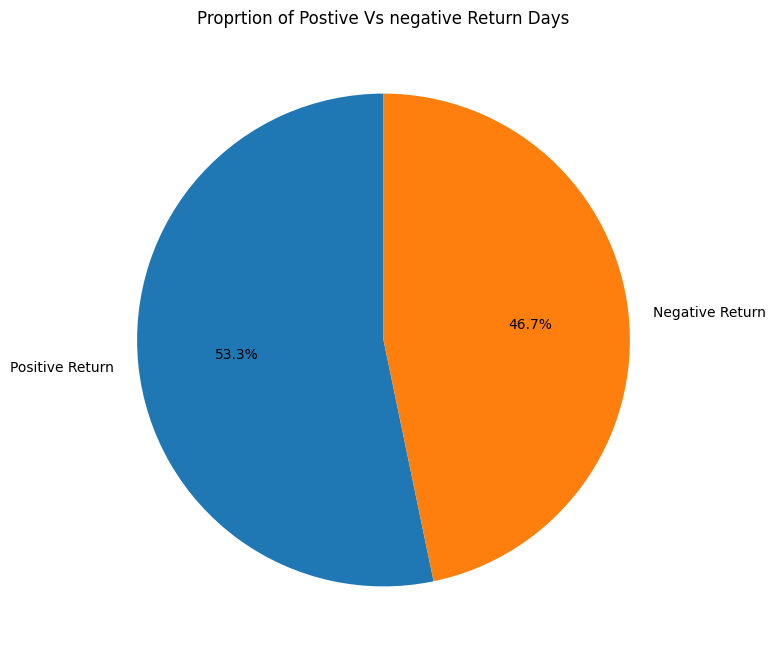

In [8]:
# PIE CHART 1 — Positive vs Negative Return Days

# creating new column 
df["Return_Type"] = df["Daily_Return"].apply(lambda x : "Positive Return" if x > 0 else "Negative Return")

return_counts = df["Return_Type"].value_counts()

#Plot pie chart 

plt.figure(figsize = ( 8 , 8 ))
plt.pie(return_counts , labels=  return_counts.index , autopct = "%1.1f%%" , startangle = 90 )  #we can't use label = df["Return_Type"] coz it has 100. rows , but counts has only 2 .  Return_counts.index means theres row i.e 2 
plt.title("Proprtion of Postive Vs negative Return Days")
plt.show()

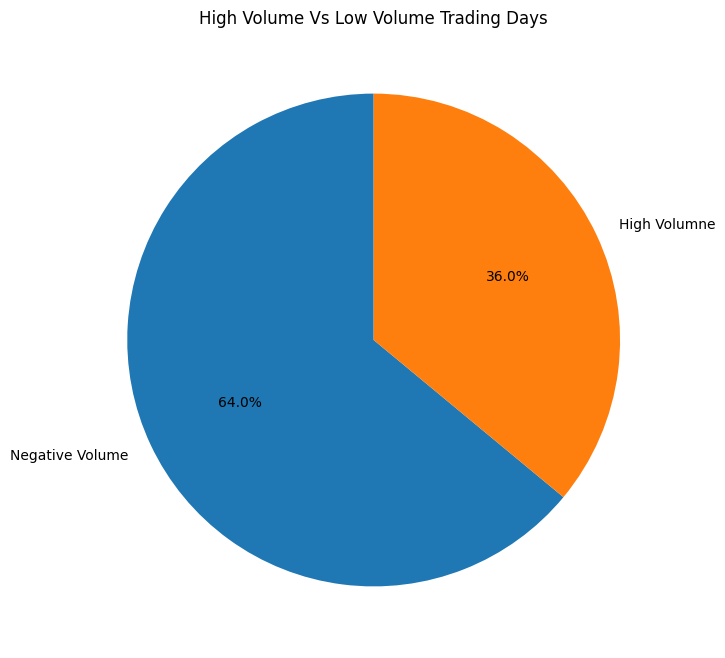

In [9]:
# PIE CHART 2 — High Volume vs Low Volume Days

avg_volume = df["Volume"].mean()

df["Volume_Type"] = df["Volume"].apply(lambda x : "High Volumne" if x > avg_volume else "Negative Volume" )

volume_counts = df["Volume_Type"].value_counts()

plt.figure(figsize = ( 8 , 8))
plt.pie(volume_counts ,labels = volume_counts.index ,autopct = '%1.1f%%', startangle= 90 )
plt.title("High Volume Vs Low Volume Trading Days")
plt.show()